Installing mace-torch, ase, and requests...


/usr/local/lib/python3.12/dist-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.

🏗️  Building inverted multi-layer thin film...
   Formula: CB10Cr4Cu18Fe19Hf18Ni3Ti18
   Atoms:   91
   Cell:    [ 9.57        8.28786311 49.84690809 90.         90.         90.        ]

🚀  Initializing Local MACE-MP-0 Calculator...
   Device: CPU
Downloading: 100.0% (42.4 MB / 42.4 MB)
Cached MACE model to /root/.cache/mace/20231203mace128L1_epoch199model
Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/usr/local/lib/python3.12/dist-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



🧪  Running geometry relaxation (FIRE)...

✅  Final energy: -65051.6289 eV

💾  Wrote mantel_multilayer.extxyz with embedded RGB colors
💾  Wrote mantel_multilayer.lmp (LAMMPS data file)


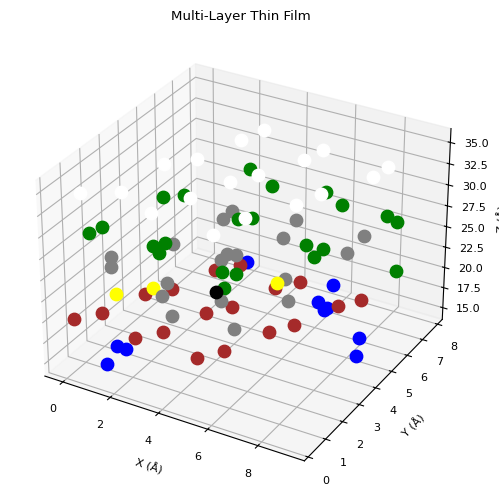

In [6]:
# ==============================================================================
# Multi-Layer Thin-Film Generator for OVITO with NVIDIA NIM Support
# Layer 1 (outer): Titanium  (HCP)
# Layer 2:          Hafnium   (HCP)
# Layer 3:          316 Steel (FCC austenitic)
# Layer 4:          Copper    (FCC)
# Layer 5:          Boron     (10-atom cap layer)
#
# Output: mantel_multilayer.extxyz  (readable by ASE and OVITO)
# ==============================================================================

# @title 1. Install Dependencies
# Run this once per fresh Colab session
import subprocess
import sys


def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "-q", "install", pkg])


print("Installing mace-torch, ase, and requests...")
install("mace-torch")
install("ase")
install("requests")

# @title 2. Imports & Setup
import random
import time
from typing import Dict, List
from ase import Atoms
from ase.build import fcc111, hcp0001
from ase.calculators.calculator import Calculator, all_changes
from ase.constraints import FixAtoms
from ase.io import write
from ase.optimize import FIRE
from google.colab import userdata
from mace.calculators import mace_mp
import numpy as np
import requests
import torch

random.seed(42)
np.random.seed(42)


# @title 3. NVIDIA NIM Custom Calculator
class MACE_NIM_Calculator(Calculator):
    """ASE Calculator interface for remote MACE models hosted on NVIDIA NIM.

    Includes automatic exponential backoff for transient network failures.
    """

    implemented_properties = ["energy", "forces"]

    def __init__(
        self,
        endpoint_url: str,
        api_key: str,
        max_retries: int = 3,
        backoff_factor: float = 1.0,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.endpoint_url = endpoint_url
        self.headers = {
            "Authorization": f"Bearer {api_key}",
            "Content-Type": "application/json",
            "Accept": "application/json",
        }
        self.max_retries = max_retries
        self.backoff_factor = backoff_factor

    def calculate(
        self,
        atoms=None,
        properties=["energy", "forces"],
        system_changes=all_changes,
    ):
        super().calculate(atoms, properties, system_changes)

        # Serialize ASE atoms object for the HTTP POST payload
        payload = {
            "atomic_numbers": self.atoms.get_atomic_numbers().tolist(),
            "positions": self.atoms.get_positions().tolist(),
            "cell": self.atoms.get_cell().tolist(),
            "pbc": self.atoms.get_pbc().tolist(),
        }

        # Network errors: The MACE_NIM_Calculator includes a retry loop for transient failures.
        for attempt in range(self.max_retries):
            try:
                response = requests.post(
                    self.endpoint_url,
                    headers=self.headers,
                    json=payload,
                    timeout=30,
                )
                response.raise_for_status()
                data = response.json()

                # Endpoint URL: The schema in the code is generic; real NIM endpoints may wrap energy/forces differently.
                # Adjust data dictionary extraction based on the specific NIM MACE API schema.
                self.results["energy"] = float(data.get("energy", 0.0))
                self.results["forces"] = np.array(
                    data.get("forces", np.zeros_like(payload["positions"])),
                    dtype=float,
                )
                return

            except (
                requests.exceptions.RequestException,
                ValueError,
                KeyError,
            ) as e:
                if attempt == self.max_retries - 1:
                    raise RuntimeError(
                        f"NIM calculation failed after {self.max_retries} attempts. Last error: {e}"
                    )
                time.sleep(self.backoff_factor * (2**attempt))


# @title 4. Layer Builders
def build_ti_layer(size=(3, 3, 2), a=2.95, c=4.68, vacuum=10.0):
    """Layer 1: Titanium HCP slab."""
    slab = hcp0001("Ti", size=size, a=a, c=c, vacuum=vacuum)
    slab.center(axis=2)
    return slab


def build_hf_layer(size=(3, 3, 2), a=3.19, c=5.05, vacuum=10.0):
    """Layer 2: Hafnium HCP slab."""
    slab = hcp0001("Hf", size=size, a=a, c=c, vacuum=vacuum)
    slab.center(axis=2)
    return slab


def build_steel_316_layer(size=(3, 3, 3), a=3.59, vacuum=10.0):
    """Layer 3: 316 stainless steel (approximate austenitic FCC composition)."""
    slab = fcc111("Fe", size=size, a=a, vacuum=vacuum)
    n = len(slab)
    symbols = ["Fe"] * n

    counts = {
        "Fe": int(0.70 * n),
        "Cr": int(0.17 * n),
        "Ni": int(0.12 * n),
        "Mo": int(0.015 * n),
        "Mn": int(0.020 * n),
        "C": max(1, int(0.005 * n)),
    }

    diff = n - sum(counts.values())
    counts["Fe"] += diff

    idx = list(range(n))
    random.shuffle(idx)
    pos = 0
    for elem, count in counts.items():
        for _ in range(count):
            symbols[idx[pos]] = elem
            pos += 1

    slab.set_chemical_symbols(symbols)
    slab.center(axis=2)
    return slab


def build_cu_layer(size=(3, 3, 2), a=3.61, vacuum=10.0):
    """Layer 4: Copper FCC slab."""
    slab = fcc111("Cu", size=size, a=a, vacuum=vacuum)
    slab.center(axis=2)
    return slab


def build_boron_cap(n_boron=10, cell_xy=(10.0, 10.0), z_pos=0.0):
    """Layer 5: A sparse 2D cap of boron atoms."""
    positions = []
    for _ in range(n_boron):
        x = random.uniform(0.0, cell_xy[0])
        y = random.uniform(0.0, cell_xy[1])
        z = z_pos + random.uniform(-0.3, 0.3)
        positions.append([x, y, z])

    b_layer = Atoms(["B"] * n_boron, positions=positions)
    b_layer.set_cell([cell_xy[0], cell_xy[1], 20.0, 90, 90, 90])
    b_layer.center()
    return b_layer


def stack_layers(layers, gap=2.0):
    """Stack ASE slabs along the z-axis with a vacuum gap between layers."""
    base = layers[0].copy()
    base.center(axis=2)

    max_a = max(l.get_cell()[0, 0] for l in layers)
    max_b = max(l.get_cell()[1, 1] for l in layers)

    base.set_cell([max_a, max_b, base.get_cell()[2, 2], 90, 90, 90])
    current_z_max = base.positions[:, 2].max()

    for layer in layers[1:]:
        layer = layer.copy()
        layer.center(axis=2)
        layer.set_cell([max_a, max_b, layer.get_cell()[2, 2], 90, 90, 90])

        z_min = layer.positions[:, 2].min()
        shift = current_z_max + gap - z_min
        layer.positions[:, 2] += shift

        base += layer
        current_z_max = base.positions[:, 2].max()

    base.set_cell([max_a, max_b, current_z_max + 15.0, 90, 90, 90])
    base.center()
    return base


# @title 5. Build the Inverted Heterostructure
print("\n🏗️  Building inverted multi-layer thin film...")

ti = build_ti_layer(size=(3, 3, 2))
hf = build_hf_layer(size=(3, 3, 2))
steel = build_steel_316_layer(size=(3, 3, 3))
cu = build_cu_layer(size=(3, 3, 2))

film = stack_layers([cu, steel, hf, ti], gap=2.0)
cell_xy = (film.get_cell()[0, 0], film.get_cell()[1, 1])
z_bottom = film.positions[:, 2].min() - 2.0
boron = build_boron_cap(n_boron=10, cell_xy=cell_xy, z_pos=z_bottom)

structure = boron + film
structure.set_cell([
    structure.get_cell()[0, 0],
    structure.get_cell()[1, 1],
    structure.positions[:, 2].max() - structure.positions[:, 2].min() + 30.0,
    90,
    90,
    90,
])
structure.center()

print(f"   Formula: {structure.get_chemical_formula()}")
print(f"   Atoms:   {len(structure)}")
print(f"   Cell:    {structure.cell.cellpar()}")

# @title 6. Calculator Execution (Select Local vs NVIDIA NIM)
# Optimization overhead: FIRE calls the calculator many times.
# With NIM, every call is an HTTP POST. For relaxation, local execution is usually faster and cheaper.
USE_NIM = False  # Set to True to test the NVIDIA NIM cloud endpoint

if USE_NIM:
    print("\n🌐  Initializing NVIDIA NIM MACE Calculator...")
    # API key security: Store it as a Colab secret named NVIDIA_NIM_API_KEY rather than hard-coding it.
    try:
        nim_api_key = userdata.get("NVIDIA_NIM_API_KEY")
    except userdata.SecretNotFoundError:
        raise ValueError(
            "Please add 'NVIDIA_NIM_API_KEY' to your Google Colab Secrets (key icon on the left sidebar)."
        )

    # Use the key in your HTTP Authorization header or calculator setup
    headers = {
        "Authorization": f"Bearer {nim_api_key}",
        "Content-Type": "application/json"
    }
    # Endpoint URL: Replace NIM_URL with the exact model URL from your NVIDIA Build dashboard.
    NIM_URL = "https://health.api.nvidia.com/v1/biology/mace/mace-mp-0/calculate"  # Example placeholder

    calc = MACE_NIM_Calculator(endpoint_url=NIM_URL, api_key=nim_api_key)
else:
    print("\n🚀  Initializing Local MACE-MP-0 Calculator...")
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"   Device: {device.upper()}")
    calc = mace_mp(model="medium", device=device, default_dtype="float32")

structure.calc = calc

# Fix the bottom-most layers (Boron + Copper) to mimic a thick substrate
n_fixed = len(boron) + len(cu)
mask = [atom.index < n_fixed for atom in structure]
structure.set_constraint(FixAtoms(mask=mask))

print("\n🧪  Running geometry relaxation (FIRE)...")
dyn = FIRE(
    structure, trajectory="mantel_relaxation.traj", logfile="mantel_opt.log"
)
dyn.run(fmax=0.05, steps=100)

print(f"\n✅  Final energy: {structure.get_potential_energy():.4f} eV")

# @title 7. Attach Colors and Write Files for OVITO
ovito_colors = {
    "Ti": [1.0, 1.0, 1.0],  # White
    "Hf": [0.0, 0.5, 0.0],  # Green
    "Fe": [0.5, 0.5, 0.5],  # Gray
    "Cr": [0.0, 0.8, 0.0],  # Bright Green
    "Ni": [1.0, 1.0, 0.0],  # Yellow
    "Mo": [0.5, 0.0, 0.5],  # Purple
    "Mn": [1.0, 0.6, 0.0],  # Orange
    "C": [0.1, 0.1, 0.1],  # Black
    "Cu": [0.6, 0.3, 0.1],  # Brown
    "B": [0.0, 0.0, 1.0],  # Blue
}

rgb_array = np.array(
    [ovito_colors.get(atom.symbol, [0.5, 0.5, 0.5]) for atom in structure]
)
structure.set_array("Color", rgb_array)

write("mantel_multilayer.extxyz", structure)
print("\n💾  Wrote mantel_multilayer.extxyz with embedded RGB colors")

write("mantel_multilayer.lmp", structure, format="lammps-data")
print("💾  Wrote mantel_multilayer.lmp (LAMMPS data file)")

# @title 8. Quick Preview (Optional)
try:
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    elem_colors = {
        "Ti": "white",
        "Hf": "green",
        "Fe": "gray",
        "Cr": "green",
        "Ni": "yellow",
        "Mo": "purple",
        "Mn": "orange",
        "C": "black",
        "Cu": "brown",
        "B": "blue",
    }

    for atom in structure:
        ax.scatter(
            *atom.position,
            c=elem_colors.get(atom.symbol, "k"),
            s=80,
            label=atom.symbol,
        )

    ax.set_xlabel("X (Å)")
    ax.set_ylabel("Y (Å)")
    ax.set_zlabel("Z (Å)")
    ax.set_title("Multi-Layer Thin Film")
    plt.show()
except Exception as e:
    print("Matplotlib preview skipped:", e)